In [1]:
import cv2
import matplotlib.pyplot as plt
import importlib
import preprocessing
importlib.reload(preprocessing)  # pick up any edits without restarting kernel

FloorPlanPreprocessor = preprocessing.FloorPlanPreprocessor

IMG_PATH = "data/PNG/raw/IIa_A01001.png"

image = cv2.imread(IMG_PATH)
if image is None:
    raise FileNotFoundError(IMG_PATH)

print(f"Loaded: {IMG_PATH}  shape={image.shape}")

Loaded: data/PNG/raw/IIa_A01001.png  shape=(2480, 3508, 3)


libpng warning: iCCP: known incorrect sRGB profile


### preprocessing / crop

/opt/homebrew/Caskroom/miniconda/base/envs/floor-plan/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


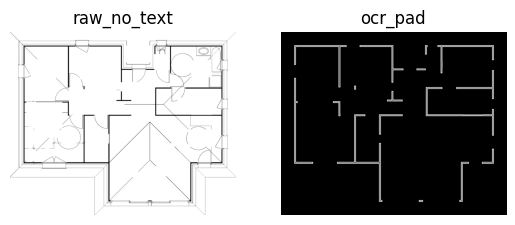

In [2]:
preprocessor = FloorPlanPreprocessor(angle_step=90)
result = preprocessor.process(image)

im = result.raw_no_text

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(result.raw_no_text, cv2.COLOR_BGR2RGB))
plt.title("raw_no_text")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result.preprocessed, cv2.COLOR_BGR2RGB))
plt.title("ocr_pad")
plt.axis("off")
plt.show()

### find wall / new method

In [ ]:
import numpy as np

def _prune_dots(binary, min_extent=25):
    """
    Drop connected components whose bounding box is short in BOTH dimensions.
    Wall fragments are elongated (long in at least one axis); dot residues
    are short in both width and height, so this preserves fine lines while
    erasing blobs regardless of pixel count.
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return binary
    keep = np.zeros_like(binary)
    for lid in range(1, num_labels):
        w = stats[lid, cv2.CC_STAT_WIDTH]
        h = stats[lid, cv2.CC_STAT_HEIGHT]
        if max(w, h) >= min_extent:
            keep[labels == lid] = 255
    return keep


def wall_filter(gray):
    """
    Filter walls
    Filter out walls from a grayscale image
    @Param image
    @Return image of walls
    """
    _, thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU,
    )

    # Line thickener - dilate before morphological operations
    thicken_kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.dilate(thresh, thicken_kernel, iterations=1)

    # noise removal
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(
        thresh,
        cv2.MORPH_OPEN,
        kernel,
        iterations=2,
    )

    sure_bg = cv2.dilate(
        opening, kernel, iterations=3
    )

    dist_transform = cv2.distanceTransform(
        opening, cv2.DIST_L2, 5
    )
    _, sure_fg = cv2.threshold(
        0.5 * dist_transform,
        0.2 * dist_transform.max(),
        255,
        0,
    )

    sure_fg = np.uint8(sure_fg)

    # Drop blob residues; keeps anything elongated in at least one axis
    sure_fg = _prune_dots(sure_fg, min_extent=25)

    return sure_fg

im_gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
wall = wall_filter(im_gray)

plt.imshow(wall, cmap='gray')
plt.title("wall filter")
plt.axis("off")
plt.show()

### full pipeline

In [16]:
# import importlib
# import pipeline as pl
# importlib.reload(pl)

# import json
# import networkx as nx

# img_path = "data/PNG/raw/IIa_BA0710.png"
# image = cv2.imread(img_path)
# if image is None:
#     raise FileNotFoundError(img_path)

# out = pl.run_pipeline(image)

# prep = out.prep
# skel = out.skel
# G    = out.graph

# n_doors   = sum(1 for o in out.json["openings"] if o["type"] == "door")
# n_windows = sum(1 for o in out.json["openings"] if o["type"] == "window")

# print(f"rotation_angle : {prep.rotation_angle}°")
# print(f"crop_bbox      : {prep.crop_bbox}")
# print(f"corners        : {len(skel.corners)}")
# print(f"walls          : {len(out.json['walls'])}")
# print(f"doors          : {n_doors}")
# print(f"windows        : {n_windows}")
# print(f"graph          : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
# print()
# print(json.dumps(out.json, indent=2))

# # Overlay: skeleton + wall edges (green) + opening edges (orange) + bboxes
# vis = cv2.cvtColor(skel.skeleton_raw, cv2.COLOR_GRAY2BGR)
# COLORS = {"wall": (0, 255, 0), "opening": (0, 165, 255)}
# for a, b, edata in G.edges(data=True):
#     pa = (int(G.nodes[a]["x"]), int(G.nodes[a]["y"]))
#     pb = (int(G.nodes[b]["x"]), int(G.nodes[b]["y"]))
#     cv2.line(vis, pa, pb, COLORS.get(edata["kind"], (200, 200, 200)), 2)
# for n, attr in G.nodes(data=True):
#     p = (int(attr["x"]), int(attr["y"]))
#     color = (0, 0, 255) if attr["kind"] == "corner" else (0, 165, 255)
#     cv2.circle(vis, p, 6, color, -1)
#     cv2.circle(vis, p, 6, (255, 255, 255), 1)
#     if "bbox" in attr:
#         x1, y1, x2, y2 = (int(v) for v in attr["bbox"])
#         cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 165, 255), 2)
#         cv2.putText(vis, f"{attr['kind']} {attr['conf']:.2f}",
#                     (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 165, 255), 1)

# plt.figure(figsize=(16, 12))
# plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
# plt.axis("off")
# plt.title(f"Floor plan graph — {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
# plt.show()